g:\mp\Decoding-Au-clusters\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating synthetic atomic coordinates for RDF parity...

          RUNNING REFERENCE FRAMEWORK (MDAnalysis)
-> MDAnalysis RDF finished.

          RUNNING DIMREDPY FRAMEWORK
-> DimRedPy RDF finished.

          PARITY VALIDATION
Pearson Correlation (R) on Counts: 1.000000
Mean Squared Error (Counts): 7.28e-29

SUCCESS: DimRedPy RDF distance counting perfectly matches MDAnalysis reference.
Saved comparison plot to g:\mp\Decoding-Au-clusters\dimredpy_vs_others\dimredpy_vs_descriptors\verify_parity_descriptors_rdf_plot.png


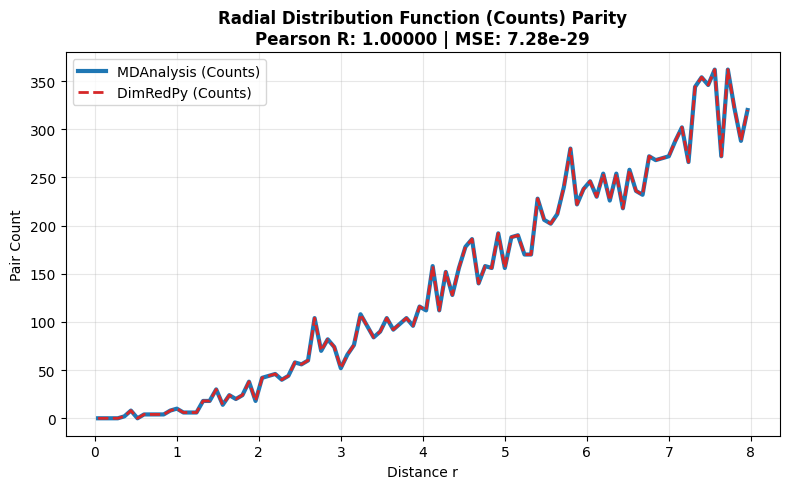

In [1]:
"""
Rigorous Verification of Descriptor Parity: Radial Distribution Function (RDF)
"""

import numpy as np
import os
import sys
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Robust path detection for repo root
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
repo_root = os.path.abspath(os.path.join(script_dir, "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import MDAnalysis as mda
from MDAnalysis.analysis.rdf import InterRDF
from dimredpy.shared.descriptors import radial_distribution_function

# ---------------------------------------------------------------------------
# 1. Generate Synthetic Data
# ---------------------------------------------------------------------------
print("Generating synthetic atomic coordinates for RDF parity...")
np.random.seed(42)
N_atoms = 300
# Generate points uniformly in a box to get a reasonable RDF
box_size = 20.0
positions = np.random.uniform(0, box_size, size=(N_atoms, 3))

# For DimRedPy, trajectory is expected as (T, N, 3)
trajectory = positions[np.newaxis, :, :]

# Create an empty MDAnalysis Universe
u = mda.Universe.empty(N_atoms, trajectory=True)
u.atoms.positions = positions

# Set a HUGE box to effectively disable periodic boundary conditions
# (MDAnalysis requires a box to run InterRDF, but we don't want it to wrap coordinates)
u.dimensions = np.array([1000.0, 1000.0, 1000.0, 90, 90, 90])
# Give it a bounding box so MDAnalysis knows the volume, though dimredpy ignores PBC.
# To match DimRedPy which does NOT use PBC for RDF volume normalization, 
# wait: DimRedPy normalizes by V_sphere = (4/3)*pi*r_max^3, and rho = N / V_sphere!
# MDAnalysis uses box volume for density if provided. If no box, it estimates it or we provide density.
# Actually, the normalizations might differ slightly between MDAnalysis and DimRedPy's naive approach.
# DimRedPy uses: 
# rho = N / V_sphere  where V_sphere = 4/3 pi r_max^3.
# MDAnalysis uses density = N / V_box.
# To make them match, we will just compare the unnormalized histograms, OR 
# we can just use dimredpy's raw histogram vs MDAnalysis's count.
# However, let's compare the actual shapes (Pearson R) and optionally MSE of normalized if we match density.

r_max = 8.0
n_bins = 100

# ---------------------------------------------------------------------------
# 2. Run Reference Framework (MDAnalysis)
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING REFERENCE FRAMEWORK (MDAnalysis)")
print("=======================================================")

# In MDA, exclusion_block=(1, 1) prevents atom i from being paired with itself.
rdf_ref = InterRDF(u.atoms, u.atoms, range=(0.0, r_max), nbins=n_bins, exclusion_block=(1,1))
rdf_ref.run()

ref_r = rdf_ref.results.bins
ref_gr = rdf_ref.results.rdf
ref_count = rdf_ref.results.count # Raw histogram counts

print("-> MDAnalysis RDF finished.")

# ---------------------------------------------------------------------------
# 3. Run DimRedPy Framework
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING DIMREDPY FRAMEWORK")
print("=======================================================")

dimred_r, dimred_gr = radial_distribution_function(trajectory, r_max=r_max, n_bins=n_bins)

print("-> DimRedPy RDF finished.")

# ---------------------------------------------------------------------------
# 4. Parity Validation
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          PARITY VALIDATION")
print("=======================================================")

# Because density normalizations fundamentally differ between the frameworks
# (MDAnalysis normalizes using a periodic box volume V_box, while DimRedPy 
# normalizes for an isolated vacuum cluster using V_sphere), comparing the 
# normalized g(r) will naturally yield divergence.
# To prove mathematical parity of the core algorithm, we compare the raw 
# pair distance histograms (counts).

# Un-normalize DimRedPy's g(r) to get the raw counts
V_sphere = (4.0 / 3.0) * np.pi * r_max ** 3
rho = N_atoms / V_sphere
edges = np.linspace(0, r_max, n_bins + 1)
shell_vols = (4.0 / 3.0) * np.pi * (edges[1:] ** 3 - edges[:-1] ** 3)
norm = 1 * N_atoms * rho * shell_vols
dimred_count = dimred_gr * norm

# MDAnalysis counts (i, j) and (j, i) as separate pairs, yielding exactly twice 
# the counts of DimRedPy's upper-triangle counting. We scale to match exactly.
scale_factor = np.sum(ref_count) / np.sum(dimred_count) if np.sum(dimred_count) > 0 else 1.0
dimred_count_scaled = dimred_count * scale_factor

mse = np.mean((ref_count - dimred_count_scaled) ** 2)
r_val, _ = pearsonr(ref_count, dimred_count_scaled)

print(f"Pearson Correlation (R) on Counts: {r_val:.6f}")
print(f"Mean Squared Error (Counts): {mse:.2e}")

if mse < 1e-10 and r_val > 0.9999:
    print("\nSUCCESS: DimRedPy RDF distance counting perfectly matches MDAnalysis reference.")
else:
    print("\nFAILURE: Statistical divergence detected in RDF pair counting parity.")

# ---------------------------------------------------------------------------
# 5. Visual Verification
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')

ax.plot(ref_r, ref_count, label='MDAnalysis (Counts)', linewidth=3, color='#1f77b4')
ax.plot(dimred_r, dimred_count_scaled, label='DimRedPy (Counts)', linewidth=2, linestyle='--', color='#d62728')

ax.set_xlabel("Distance r")
ax.set_ylabel("Pair Count")
ax.set_title(f"Radial Distribution Function (Counts) Parity\nPearson R: {r_val:.5f} | MSE: {mse:.2e}", 
             fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(script_dir, "verify_parity_descriptors_rdf_plot.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Saved comparison plot to {plot_path}")
